In [1]:
# Import packages
from typing import Optional
import phenograph
import scanpy as sc
from anndata import AnnData
from anndata import concat
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import os
import pandas as pd
import numpy as np
from scipy.stats import entropy
import subprocess
import palantir
import sys
import random
from collections import OrderedDict
import re
from itertools import chain
import warnings
sys.path.append('/lila/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages')
import harmony
from scipy.sparse import coo_matrix
from sklearn.neighbors import NearestNeighbors
from phenograph.core import find_neighbors, neighbor_graph, jaccard_kernel
from matplotlib import pyplot as plt
%matplotlib inline
import math
from scipy.stats import wasserstein_distance, ttest_ind, zscore, norm

findfont: Font family ['Raleway'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Lato'] not found. Falling back to DejaVu Sans.


In [3]:
# Read in adata
adata_full = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.leiden.h5ad')

In [6]:
adata_full

AnnData object with n_obs × n_vars = 52800 × 31806
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden', 'leiden_res_.25', 'leiden_res_.5', 'leiden_res_1', 'leiden_res_0.1'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'diffmap_evals', 'hvg', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes

In [2]:
# Read in adata
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.fdl.h5ad')

In [7]:
adata

AnnData object with n_obs × n_vars = 53296 × 439
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'original_total_counts', 'log10_original_total_counts', 'Cell State', 'Patient', 'Tissue'
    uns: 'Cell State_colors'
    obsm: 'X_fdl_harmony', 'X_pca', 'X_umap', 'aff_mat', 'aug_mat'

In [9]:
# Make sure that adata and adata_full have the same cells so that we can add
# The cell state information to the adata
common_cells = adata.obs_names.intersection(adata_full.obs_names)
adata = adata[common_cells, :]
adata_full = adata_full[common_cells, :]
adata_full.obs['Cell State'] = adata.obs['Cell State'].loc[common_cells]

/scratch/lsftmp/4402366.tmpdir/ipykernel_50415/853749082.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_full.obs['Cell State'] = adata.obs['Cell State'].loc[common_cells]


In [10]:
# Perform wilcoxon rank-sum test to identify DEGs
#sc.tl.rank_genes_groups(adata_patient, groupby='Cell State', method='wilcoxon', key_added='wilcoxon', n_genes=100, use_raw=False)
sc.tl.rank_genes_groups(adata_full, groupby='Cell State', method='wilcoxon', n_genes=100, use_raw=False)

In [11]:
# Subset the DEGs to include those that are highly significant
# log-fold change greater than 3, adjusted p-value less than 0.001
sig_degs_df = sc.get.rank_genes_groups_df(adata_full, group=['ISC', 'Injury Repair', 
                                                  'Squamous', 'Proliferative', 
                                                  'Secretory', 'Absorptive', 'Fetal', 
                                                  'Neuroendocrine'], 
                                         )#pval_cutoff=0.001, log2fc_min=3)
sig_degs_df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,ISC,MT-CYB,14.757565,0.469958,2.750290e-49,3.976169e-46
1,ISC,MT-ND1,14.284688,0.424137,2.726289e-46,3.468493e-43
2,ISC,MT-CO2,13.152602,0.357832,1.644176e-39,1.162103e-36
3,ISC,PHGR1,11.248047,0.730792,2.367774e-29,7.530943e-27
4,ISC,LINC00511,10.937037,0.881010,7.666515e-28,2.157886e-25
...,...,...,...,...,...,...
795,Neuroendocrine,RPS19,8.520295,0.864490,1.591467e-17,4.730671e-15
796,Neuroendocrine,TSPO,8.516437,1.290298,1.645380e-17,4.845645e-15
797,Neuroendocrine,DEFA6,8.512607,1.794625,1.700666e-17,4.962514e-15
798,Neuroendocrine,ADD3,8.433066,0.935877,3.367236e-17,9.736209e-15


In [12]:
adata2 = adata_full.copy()

In [13]:
sc.pp.scale(adata2)

In [41]:
# Define NE Degs
ne_deg_df = sig_degs_df[sig_degs_df['group'] == 'Neuroendocrine']
ne_deg_df

# Define NE Degs (Curated List)
ne_deg_df_curated = ['CHGA', 'CHGB', 'ASCL1', 'NEUROD1', 'INSM1', 'SYP', 'ENO2', 'NCAM1']

In [43]:
#ZSCORE FOR NE GENES
for num_genes in [50, 100]:
#     ind1 = ne_deg_df.loc[:,'pvals_adj'] < 0.001
#     ind2 = ne_deg_df.loc[:,'logfoldchanges'] > 1.5
#     ind3 = ne_deg_df.names.isin(adata2.var_names)
#     ind = ind1.values & ind2.values & ind3.values
#     ne_deg = list(ne_deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = ne_deg_df_curated, score_name = 'zscore_' + 'ne_curated', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)
    

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

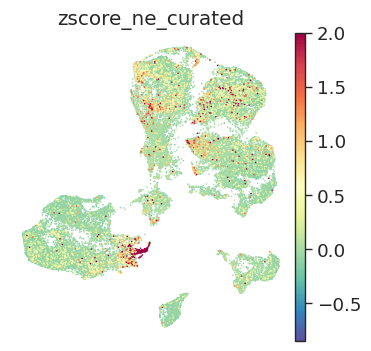

In [49]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_ne_curated'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           vmax= [2],
           s=5,
           use_raw = False,
           frameon = False)

In [50]:
# Define Squamous Degs
sq_deg_df = sig_degs_df[sig_degs_df['group'] == 'Squamous']
sq_deg_df

sq_deg_df_curated = ['ESRRA', 'CD44', 'EPCAM', 'CAV1']

In [51]:
#ZSCORE FOR SQUAMOUS GENES
for num_genes in [50, 100]:
#     ind1 = sq_deg_df.loc[:,'pvals_adj'] < 0.001
#     ind2 = sq_deg_df.loc[:,'logfoldchanges'] > 1.5
#     ind3 = sq_deg_df.names.isin(adata2.var_names)
#     ind = ind1.values & ind2.values & ind3.values
#     sq_deg = list(sq_deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = sq_deg_df_curated, score_name = 'zscore_' + 'squamous_curated', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)
    

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

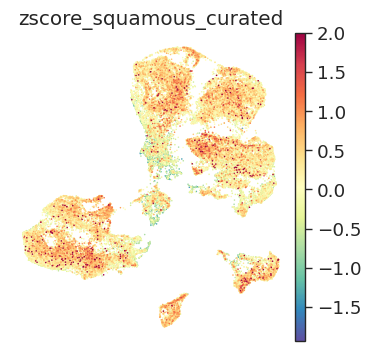

In [55]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_squamous_curated'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           vmax= [2],
           s=5,
           use_raw = False,
           frameon = False)

In [162]:
# Define ISC Degs
isc_deg_df = sig_degs_df[sig_degs_df['group'] == 'ISC']
isc_deg_df

isc_deg_df_curated = ['LGR5','ASCL2', 'SLC12A2', 'AXIN2', 'OLFM4']

isc_deg_df_curated_longlist = ['ASCL2', 'SOX9', 'SOX4','LGR5', 'AXIN2']

In [163]:
#ZSCORE FOR ISC GENES
for num_genes in [50, 100]:
#     ind1 = isc_deg_df.loc[:,'pvals_adj'] < 0.001
#     ind2 = isc_deg_df.loc[:,'logfoldchanges'] > 1.5
#     ind3 = isc_deg_df.names.isin(adata2.var_names)
#     ind = ind1.values & ind2.values & ind3.values
#     isc_deg = list(isc_deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = isc_deg_df_curated_longlist, score_name = 'zscore_' + 'isc_curated_long', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)
    

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

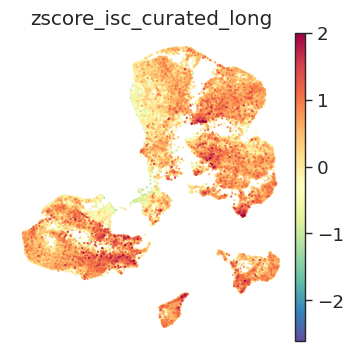

In [167]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_isc_curated_long'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           vmax= [2],
           s=10,
           use_raw = False,
           frameon = False)

In [75]:
# Define Absorptive Degs
abs_deg_df = sig_degs_df[sig_degs_df['group'] == 'Absorptive']
abs_deg_df

abs_deg_df_curated = ['CA1', 'FABP1', 'ANPEP', 'GUCA2A', 'IL32', 'SELENBP1', 'EMP1']

In [76]:
#ZSCORE FOR ABSORPTIVE GENES
for num_genes in [50, 100]:
#     ind1 = abs_deg_df.loc[:,'pvals_adj'] < 0.001
#     ind2 = abs_deg_df.loc[:,'logfoldchanges'] > 1.5
#     ind3 = abs_deg_df.names.isin(adata2.var_names)
#     ind = ind1.values & ind2.values & ind3.values
#     abs_deg = list(abs_deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = abs_deg_df_curated, score_name = 'zscore_' + 'abs_curated', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)
    

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

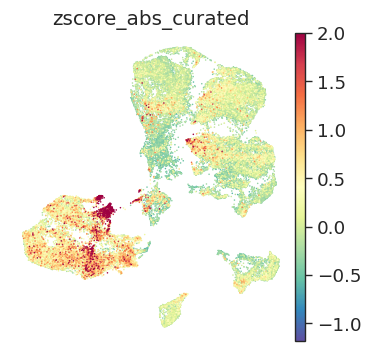

In [79]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_abs_curated'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           vmax= [2],
           s=5,
           use_raw = False,
           frameon = False)

In [68]:
# Define Injury Repair Degs
inj_deg_df = sig_degs_df[sig_degs_df['group'] == 'Injury Repair']
inj_deg_df

inj_deg_df_curated = ['TACSTD2', 'ANXA1', 'L1CAM', 'EMP1']

In [69]:
#ZSCORE FOR INJURY REPAIR GENES
for num_genes in [50, 100]:
#     ind1 = inj_deg_df.loc[:,'pvals_adj'] < 0.001
#     ind2 = inj_deg_df.loc[:,'logfoldchanges'] > 1.5
#     ind3 = inj_deg_df.names.isin(adata2.var_names)
#     ind = ind1.values & ind2.values & ind3.values
#     inj_deg = list(inj_deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = inj_deg_df_curated, score_name = 'zscore_' + 'inj_curated', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)
    

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

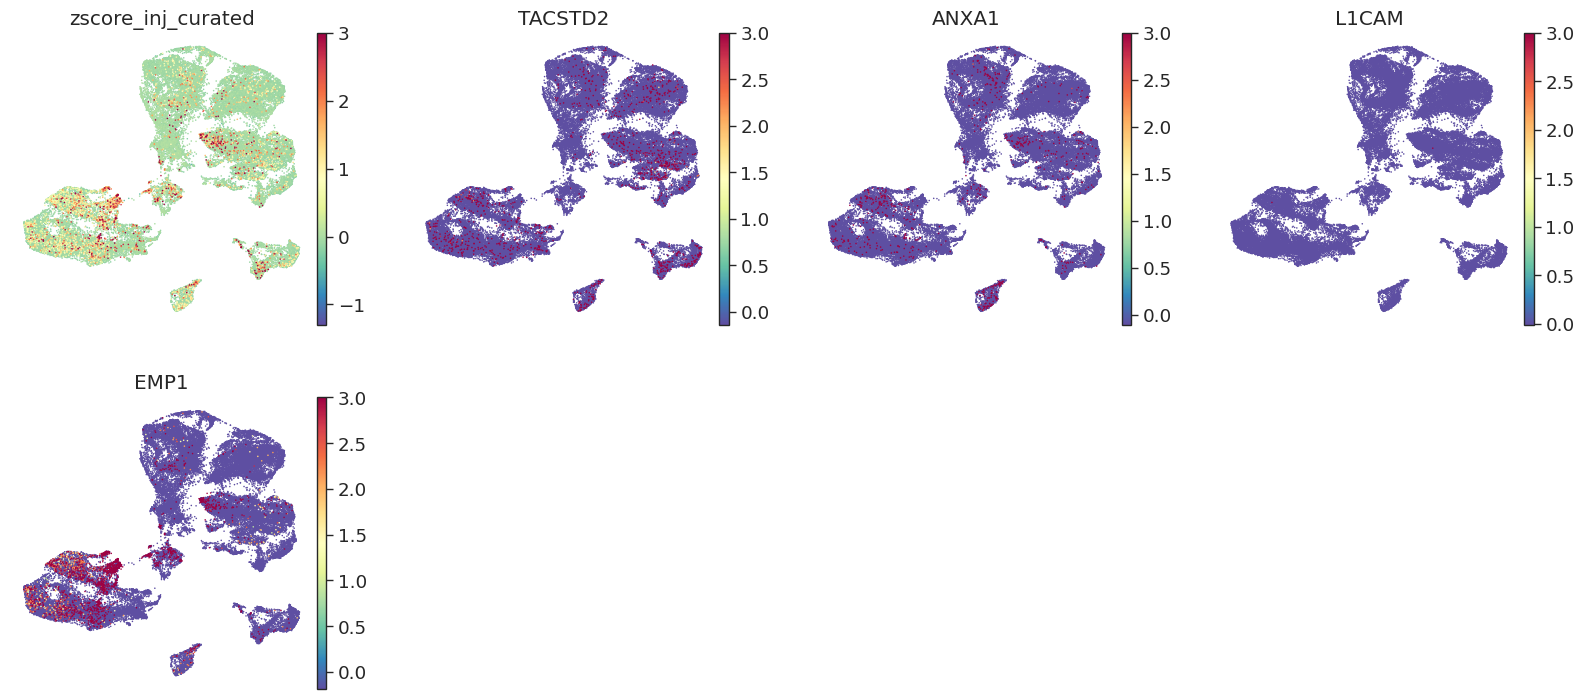

In [89]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_inj_curated', 'TACSTD2', 'ANXA1', 'L1CAM', 'EMP1'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           vmax= [3],
           s=5,
           use_raw = False,
           frameon = False)

In [172]:
# Define TA-like/Proliferative Degs
prolif_deg_df = sig_degs_df[sig_degs_df['group'] == 'Proliferative']
prolif_deg_df

prolif_deg_df_long_list = "HMGB1;LDHB;H2AFZ;STMN1;HMGN2;NASP;MKI67;CENPW;DNMT1;CCNB1;MAD2L1;UBE2C;DDX39A;CDC20;TUBA1B;SMC4"
prolif_deg_df_long_list = prolif_deg_df_long_list.split(';')
print(prolif_deg_df_long_list)

['HMGB1', 'LDHB', 'H2AFZ', 'STMN1', 'HMGN2', 'NASP', 'MKI67', 'CENPW', 'DNMT1', 'CCNB1', 'MAD2L1', 'UBE2C', 'DDX39A', 'CDC20', 'TUBA1B', 'SMC4']


In [173]:
#ZSCORE FOR PROLIFERATIVE GENES
for num_genes in [50, 100]:
#     ind1 = prolif_deg_df.loc[:,'pvals_adj'] < 0.001
#     ind2 = prolif_deg_df.loc[:,'logfoldchanges'] > 1.5
#     ind3 = prolif_deg_df.names.isin(adata2.var_names)
#     ind = ind1.values & ind2.values & ind3.values
#     prolif_deg = list(prolif_deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = prolif_deg_df_long_list, score_name = 'zscore_' + 'prolif_long', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)
    

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

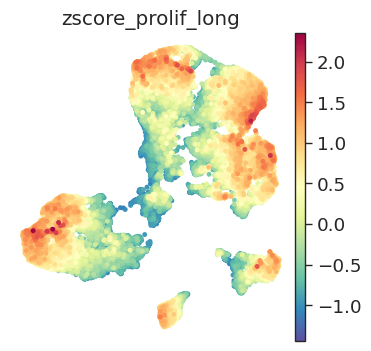

In [174]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_prolif_long'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           #vmax= [0.5],
           s=50,
           use_raw = False,
           frameon = False)

In [80]:
# Define Secretory Degs
sec_deg_df = sig_degs_df[sig_degs_df['group'] == 'Secretory']
sec_deg_df

sec_deg_df_curated = ['ZG16', 'TFF1', 'CLIC4', 'CEACAM5', 'MUC1']

In [81]:
#ZSCORE FOR SECRETORY GENES
for num_genes in [50, 100]:
#     ind1 = sec_deg_df.loc[:,'pvals_adj'] < 0.001
#     ind2 = sec_deg_df.loc[:,'logfoldchanges'] > 1.5
#     ind3 = sec_deg_df.names.isin(adata2.var_names)
#     ind = ind1.values & ind2.values & ind3.values
#     sec_deg = list(sec_deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = sec_deg_df_curated, score_name = 'zscore_' + 'sec_curated', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)
    

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

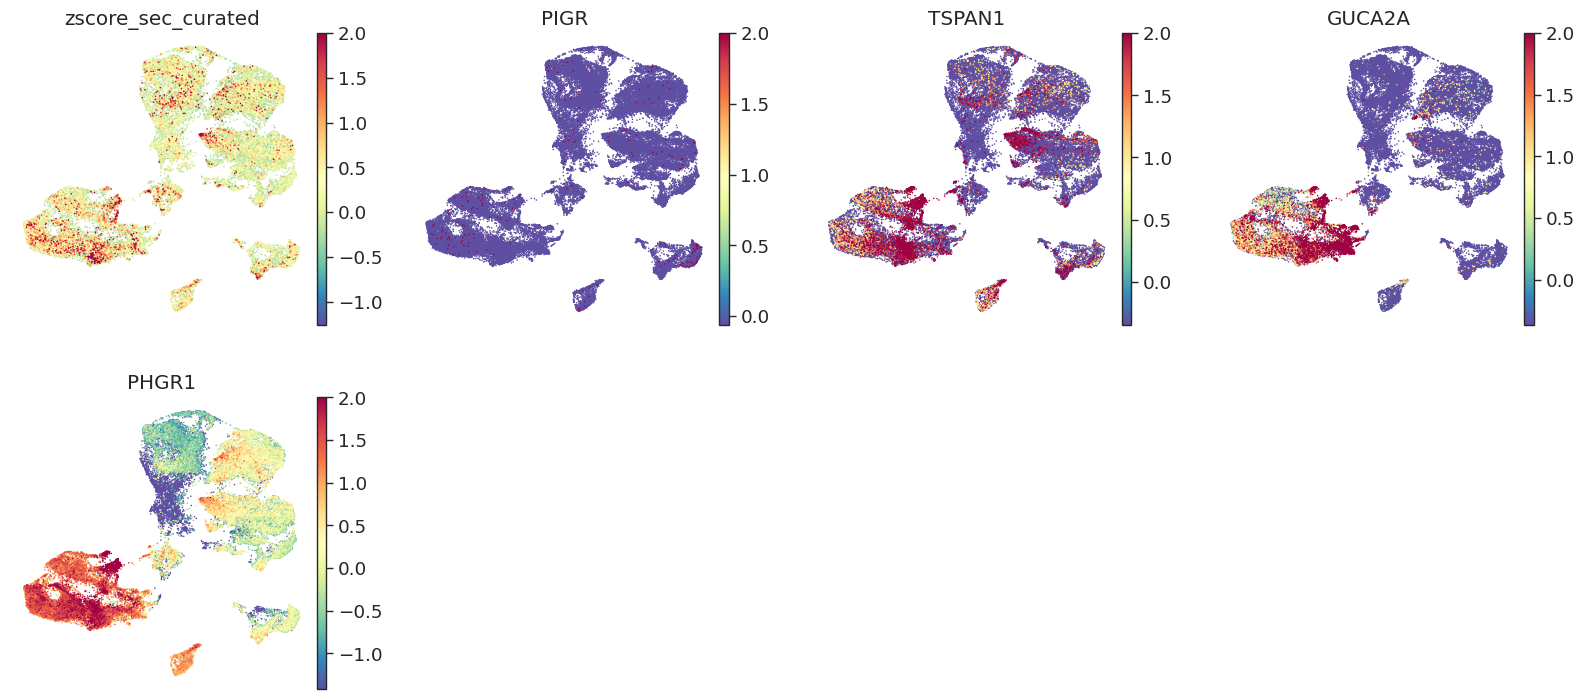

In [99]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_sec_curated', 'PIGR', 'TSPAN1', 'GUCA2A', 'PHGR1'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           vmax= [2],
           s=5,
           use_raw = False,
           frameon = False)

In [65]:
# Define Fetal Degs
fetal_deg_df = sig_degs_df[sig_degs_df['group'] == 'Fetal']
fetal_deg_df

fetal_deg_df_curated = ['PROX1', 'GPC1', 'HYAL2', 'TMEM132A']

In [66]:
#ZSCORE FOR FETAL GENES
for num_genes in [50, 100]:
#     ind1 = fetal_deg_df.loc[:,'pvals_adj'] < 0.001
#     ind2 = fetal_deg_df.loc[:,'logfoldchanges'] > 1.5
#     ind3 = fetal_deg_df.names.isin(adata2.var_names)
#     ind = ind1.values & ind2.values & ind3.values
#     fetal_deg = list(fetal_deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = fetal_deg_df_curated, score_name = 'zscore_' + 'fetal_curated', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)
                                        

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

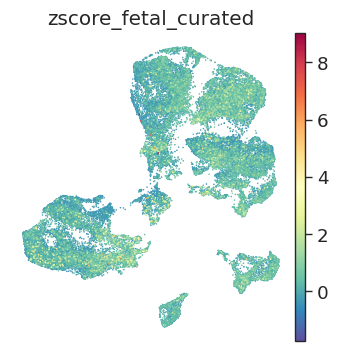

In [67]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_fetal_curated'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           #vmax= [0.5],
           s=5,
           use_raw = False,
           frameon = False)

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

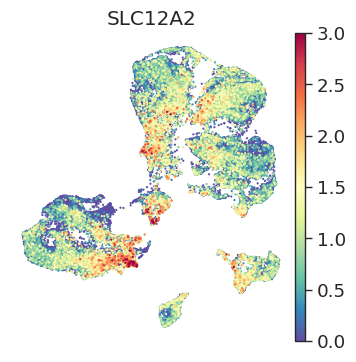

In [153]:
'''
GENE MARKERS FOR NEUROENDOCRINE CELLS
'''
sc.pl.umap(adata2, 
           color=['SLC12A2'], 
           cmap = 'Spectral_r',
           vmin=[0],
           vmax= [3],
           s=10,
           use_raw = False,
           frameon = False)

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

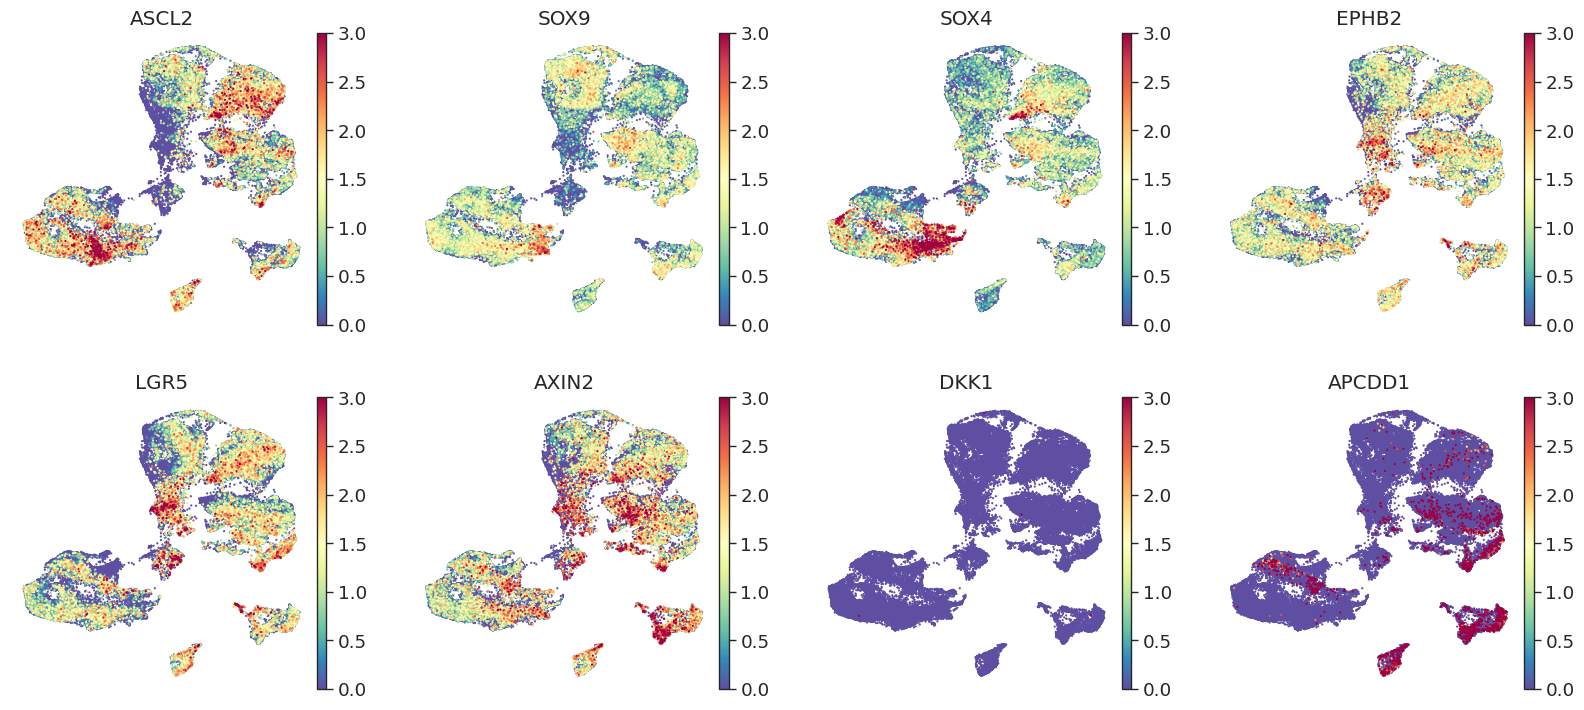

In [124]:
'''
GENE MARKERS FOR INJURY REPAIR CELLS
'''
sc.pl.umap(adata2, 
           color=['ASCL2', 'SOX9', 'SOX4', 'EPHB2', 'LGR5', 'AXIN2', 'DKK1', 'APCDD1'], 
           cmap = 'Spectral_r',
           vmin=[0],
           vmax= [3],
           s=10,
           use_raw = False,
           frameon = False)

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

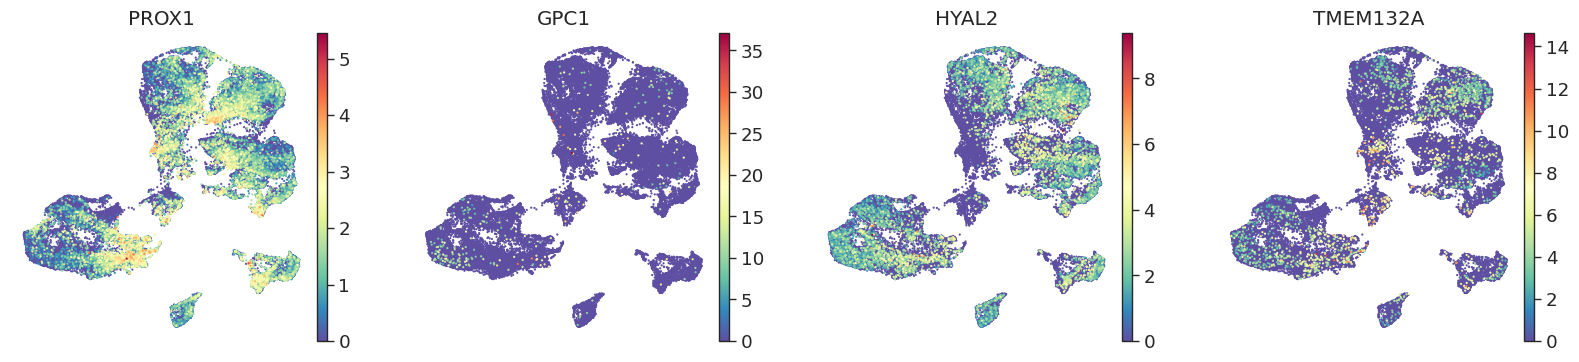

In [157]:
'''
GENE MARKERS FOR FETAL CELLS
'''
sc.pl.umap(adata2, 
           color=['PROX1' ,'GPC1', 'HYAL2', 'TMEM132A'], 
           cmap = 'Spectral_r',
           vmin=[0],
           #vmax= [5],
           s=10,
           use_raw = False,
           frameon = False)

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

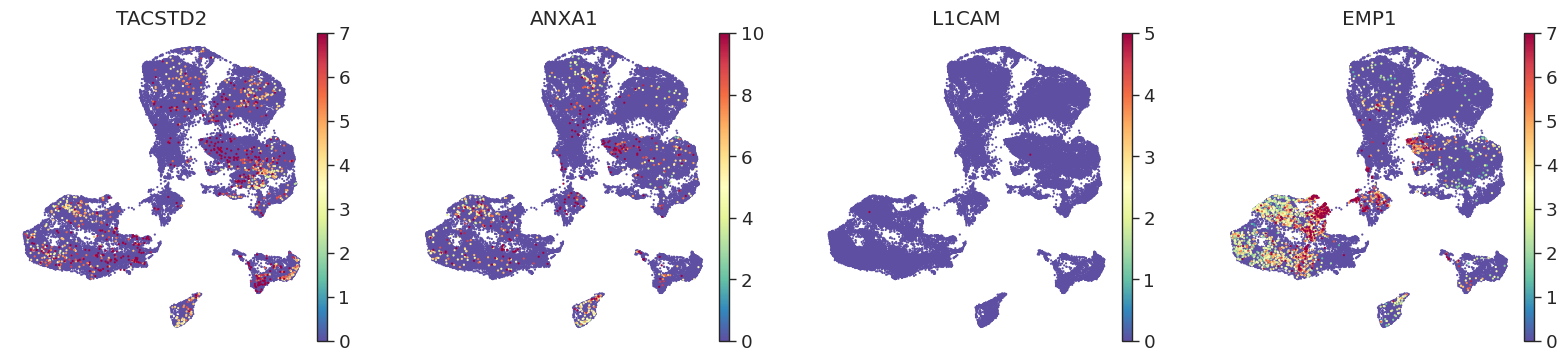

In [161]:
'''
GENE MARKERS FOR INJURY REPAIR CELLS
'''
sc.pl.umap(adata2, 
           color=['TACSTD2', 'ANXA1', 'L1CAM', 'EMP1'], 
           cmap = 'Spectral_r',
           vmin=[0],
           vmax= [7, 10, 5, 7],
           s=10,
           use_raw = False,
           frameon = False)

In [48]:
sc.pp.neighbors(adata2, n_neighbors=15)
sc.tl.umap(adata2)

In [76]:
deg_df = sig_degs_df[sig_degs_df['group'] == 'ISC']
deg_df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,ISC,MT-ND1,14.577626,0.589046,3.898404e-48,3.422799e-46
1,ISC,LGALS3,10.832165,0.640565,2.423563e-27,5.599707e-26
2,ISC,TOMM40,9.498641,0.797450,2.126477e-21,2.828859e-20
3,ISC,ACTN4,8.984095,0.396130,2.608739e-19,2.863092e-18
4,ISC,LGALS4,8.666751,0.594585,4.446248e-18,4.337562e-17
...,...,...,...,...,...,...
95,ISC,GPA33,1.171307,0.159991,2.414752e-01,3.183412e-01
96,ISC,ARID3A,1.151831,0.143075,2.493906e-01,3.277918e-01
97,ISC,RANBP1,1.091499,0.007283,2.750535e-01,3.593705e-01
98,ISC,EPHB2,1.076373,0.070724,2.817605e-01,3.670411e-01


/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font 

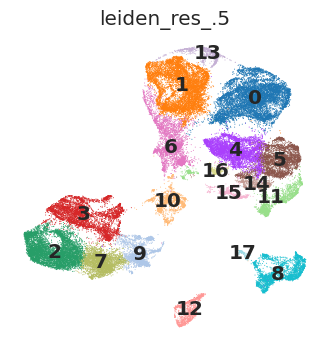

In [85]:
# Plot QC metrics
sc.pl.umap(adata_full, 
           color=['leiden_res_.5'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           #vmax= [0.5],
           s=2,
           use_raw = False,
           frameon = False, 
           legend_loc='on data')

In [77]:
#FINALIZE SCORE
for num_genes in [50, 100]:
    ind1 = deg_df.loc[:,'pvals_adj'] < 0.001
    ind2 = deg_df.loc[:,'logfoldchanges'] > 1.0
    ind3 = deg_df.names.isin(adata2.var_names)
    ind = ind1.values & ind2.values & ind3.values
    ne_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = ne_deg, score_name = 'zscore_' + 'isc', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)

# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_isc'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           #vmax= [0.5],
           s=50,
           use_raw = False,
           frameon = False)

ValueError: No valid genes were passed for scoring.

In [49]:
adata2.obs['zscore_ne']

160372412528502_KG146M                                    0.027488
120729984154461_KG146P                                    0.111181
165310954358702_KG146P                                    0.133173
227929307962076_KG146M                                    0.399704
230670678277404_KG146P                                    0.058373
                                                            ...   
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1         -0.144817
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1               0.202016
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1              -0.068608
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1        -0.083801
146Li_dedifferentiation_shZFP36L2_4_AACAACCAGGGAGAAT-1    0.162294
Name: zscore_ne, Length: 53296, dtype: float64

In [50]:
adata2.obs['zscore_absorptive']

160372412528502_KG146M                                    0.027488
120729984154461_KG146P                                    0.111181
165310954358702_KG146P                                    0.133173
227929307962076_KG146M                                    0.399704
230670678277404_KG146P                                    0.058373
                                                            ...   
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1         -0.144817
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1               0.202016
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1              -0.068608
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1        -0.083801
146Li_dedifferentiation_shZFP36L2_4_AACAACCAGGGAGAAT-1    0.162294
Name: zscore_absorptive, Length: 53296, dtype: float64

/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font 

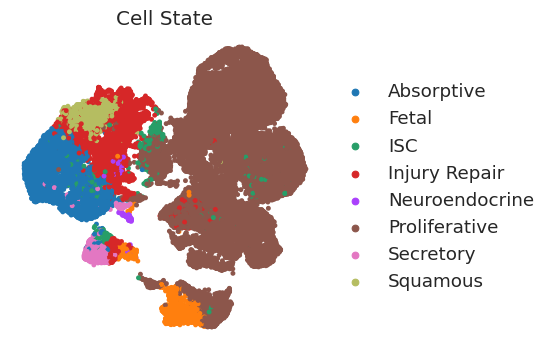

In [60]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['Cell State'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           #vmax= [0.5],
           s=50,
           use_raw = False,
           frameon = False)

KeyError: 'Could not find key CHGB in .var_names or .obs.columns.'

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

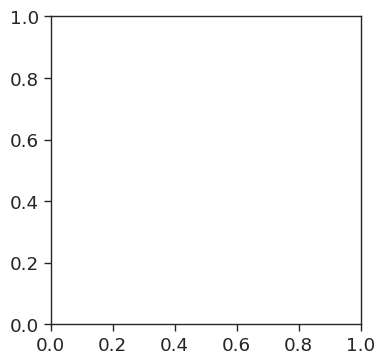

In [62]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['CHGB'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           #vmax= [0.5],
           s=50,
           use_raw = False,
           frameon = False)

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

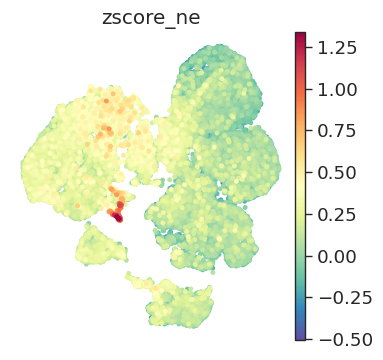

In [51]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_ne'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           #vmax= [0.5],
           s=50,
           use_raw = False,
           frameon = False)

In [58]:
#FINALIZE SCORE
for num_genes in [0, 800]:
    ind1 = deg_df.loc[:,'pvals_adj'] < 0.001
    ind2 = deg_df.loc[:,'logfoldchanges'] > 1.5
    ind3 = deg_df.names.isin(adata2.var_names)
    ind = ind1.values & ind2.values & ind3.values
    fetal_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = fetal_deg, score_name = 'zscore_' + 'fetal', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)
    

ValueError: No valid genes were passed for scoring.

In [59]:
deg_df.names.isin(adata2.var_names)

0      True
1      True
2      True
3      True
4      True
       ... 
795    True
796    True
797    True
798    True
799    True
Name: names, Length: 800, dtype: bool

In [55]:
adata2.obs['zscore_fetal']

160372412528502_KG146M                                    0.027488
120729984154461_KG146P                                    0.111181
165310954358702_KG146P                                    0.133173
227929307962076_KG146M                                    0.399704
230670678277404_KG146P                                    0.058373
                                                            ...   
146P_dedifferentiation_shCtrl_CTCCGATTCATTCATC-1         -0.144817
KG146Li_BASE_shZFP36L2_4_CTGCTCAAGTAGCAAT-1               0.202016
KG146Li_HISC_shZFP36L2_4_ATCCCTGCACGCTTAA-1              -0.068608
146Li_dedifferentiation_shCtrl_TACTTGTGTCTTACAG-1        -0.083801
146Li_dedifferentiation_shZFP36L2_4_AACAACCAGGGAGAAT-1    0.162294
Name: zscore_fetal, Length: 53296, dtype: float64

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

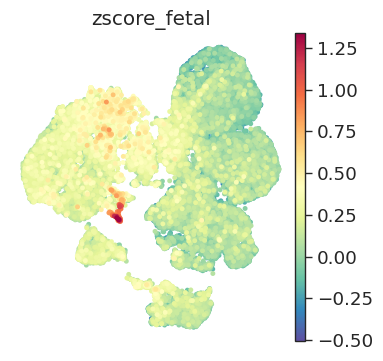

In [53]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_fetal'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           #vmax= [0.5],
           s=50,
           use_raw = False,
           frameon = False)

In [44]:
#FINALIZE SCORE
for num_genes in [500, 600]:
    ind1 = deg_df.loc[:,'pvals_adj'] < 0.001
    ind2 = deg_df.loc[:,'logfoldchanges'] > 1.5
    ind3 = deg_df.names.isin(adata2.var_names)
    ind = ind1.values & ind2.values & ind3.values
    absorptive_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=False).names[:num_genes])

#     ind2 = deg_df.loc[:,'logfoldchanges'] < -1.5
#     ind = ind1.values & ind2.values & ind3.values
#     lusc_deg = list(deg_df.loc[ind,:].sort_values('logfoldchanges', ascending=True).gene[:num_genes])
    
#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(LUAD|LUSC)', regex=True)]
#     adata2.obs = adata2.obs.drop(keys, axis=1)

    sc.tl.score_genes(adata2, gene_list = absorptive_deg, score_name = 'zscore_' + 'absorptive', use_raw = False)
#     sc.tl.score_genes(adata2, gene_list = lusc_deg,score_name = 'zscore_' + 'LUSC', use_raw = False)

#     keys = adata2.obs.columns[adata2.obs.columns.str.contains('zscore_(ne)', regex=True)]
#     adata2.obs.loc[:,keys] = adata2.obs.loc[:,keys].apply(zscore)


findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

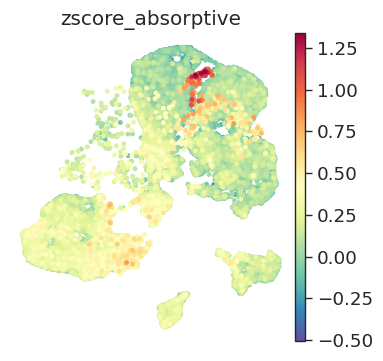

In [45]:
# Plot QC metrics
sc.pl.umap(adata2, 
           color=['zscore_absorptive'], 
           cmap = 'Spectral_r',
           #vmin=[0],
           #vmax= [0.5],
           s=50,
           use_raw = False,
           frameon = False)